**Bivariate-Multivariate analysis**

In [1]:
# Import the packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_path="C:\\DS_Py\\Visadataset.csv"
visa_df=pd.read_csv(file_path)
visa_df.head(5)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [6]:
visa_df['continent'].value_counts()

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

In [7]:
visa_df['case_status'].value_counts()

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

In [16]:
# out of all asian applicants how many got visa
# out of all europe applicants how many got visa

con1=visa_df['continent']=='Asia'
con2=visa_df['case_status']=='Certified'
con=con1&con2
visa_df[con]

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.65,Year,Y,Certified
5,EZYV06,Asia,Master's,Y,N,2339,2012,South,78252.14,Year,Y,Certified
6,EZYV07,Asia,Bachelor's,N,N,4985,1994,South,53635.39,Year,Y,Certified
8,EZYV09,Asia,Bachelor's,N,N,4810,2012,Midwest,74362.19,Year,Y,Certified
10,EZYV11,Asia,Master's,N,N,2465,2004,Midwest,83588.56,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified


In [28]:
# generalised
labels=visa_df['continent'].unique()
certified_count=[]
denied_count=[]
for i in labels:
    con1=visa_df['continent']==i
    con2=visa_df['case_status']=='Certified'
    con3=visa_df['case_status']=='Denied'
    certified_count.append(len(visa_df[con1&con2]))
    denied_count.append(len(visa_df[con1&con3]))

labels,certified_count,denied_count

pd.DataFrame(zip(labels,certified_count,denied_count),columns=['continent','case_status','Denied'])

,continent,case_status,Denied
0,Asia,11012,5849
1,Africa,397,154
2,North America,2037,1255
3,Europe,2957,775
4,South America,493,359
5,Oceania,122,70


$pd.crosstab$

In [31]:
# shortcut

con1=visa_df['continent']
con2=visa_df['case_status']
result1=pd.crosstab(con1,con2)
result1

case_status,Certified,Denied
continent,,
Africa,397,154
Asia,11012,5849
Europe,2957,775
North America,2037,1255
Oceania,122,70
South America,493,359


<Axes: xlabel='continent'>

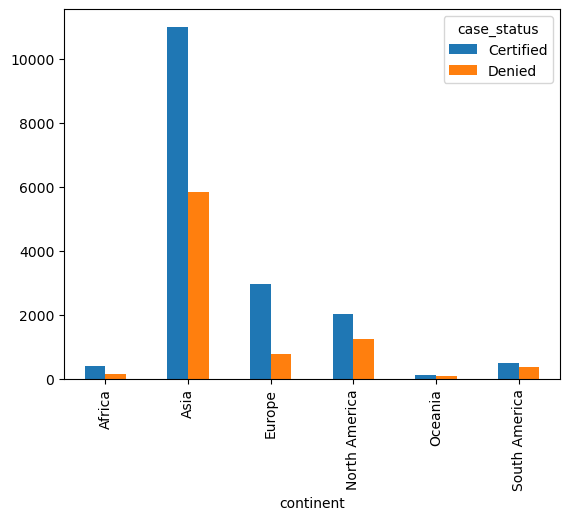

In [32]:
result1.plot(kind='bar')

In [35]:
#atke 3 columns, continent
# Education
# case status
con1=visa_df['continent']
con2=visa_df['case_status']
con3=visa_df['education_of_employee']         # crosstab is only for==1 index and 1 column, so we are combining con2 & con3
col=[con2,con3]
result2=pd.crosstab(con1,col)
result2

case_status            Certified                                    Denied  \
education_of_employee Bachelor's Doctorate High School Master's Bachelor's   
continent                                                                    
Africa                        81        43          23      250         62   
Asia                        4407       780         676     5149       2761   
Europe                      1040       788         162      967        259   
North America                641       207         210      979        584   
Oceania                       38        19          19       46         28   
South America                160        75          74      184        173   

case_status                                           
education_of_employee Doctorate High School Master's  
continent                                             
Africa                       11          43       38  
Asia                        143        1614     1331  
Europe                       58         328      130  
North America                51         191      429  
Oceania                       3          17       22  
South America                14          63      109

<Axes: xlabel='continent'>

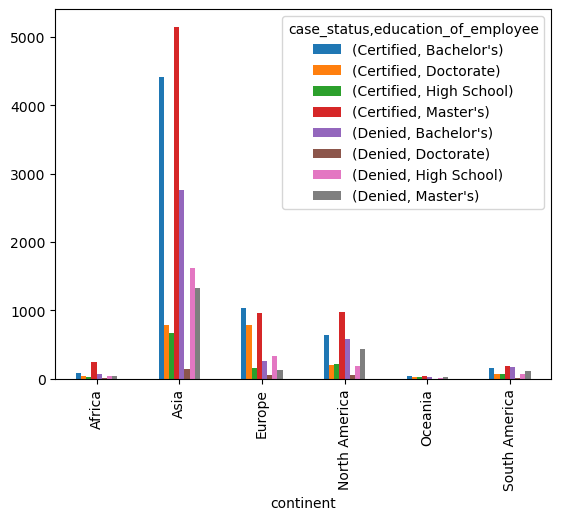

In [36]:
result2.plot(kind='bar')

**Numerical vs Numerical**

$plt.scatter$

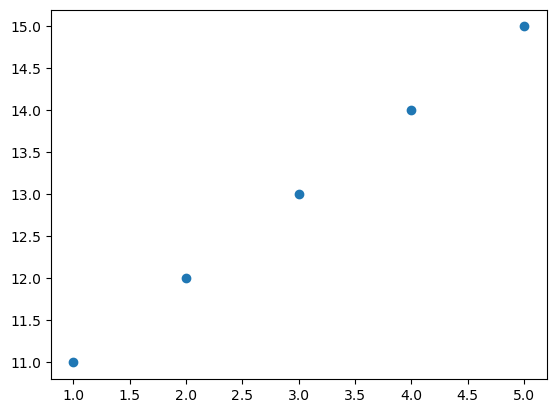

In [44]:
# scatter plot is only for numerical analysis

x=[1,2,3,4,5]
y=[11,12,13,14,15]

plt.scatter(x,y)

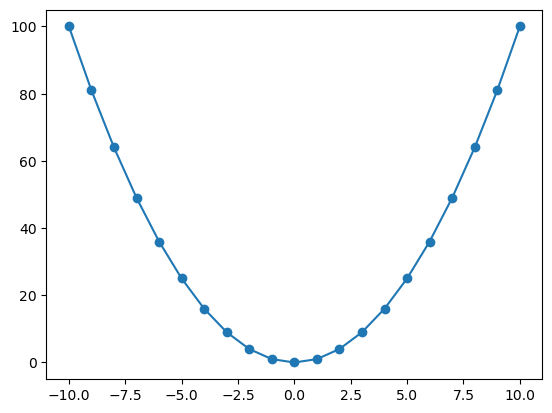

In [43]:
# parabola
x=[i for i in range(-10,11)]
y=[i*i for i in x]
x
y
plt.scatter(x,y)
plt.plot(x,y)

- scatter plot is only for numerical analysis
- scatter plots provides an idea, both variables are related or not related
- positive relation
    - increase in curve
- negative relation
    - decrease in curve
- no relation
    - Neither increase nor decrease

In [54]:
dtypes=dict(visa_df.dtypes)
num=[i for i in dtypes if dtypes[i]!='O']
num

['no_of_employees', 'yr_of_estab', 'prevailing_wage']

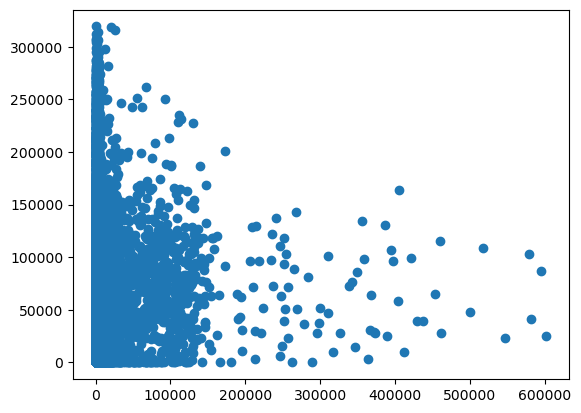

In [56]:
x=visa_df['no_of_employees']
y=visa_df['prevailing_wage']

plt.scatter(x,y)

In [ ]:
# covariance-matrix

# how many numerical variables are there : 3

#                   no_employee      yr        wage
  
# no_employee        var            cov        cov

#yr                  cov            var        cov

#wage                cov            cov        var 

$correlation-coefficient$
- Denoted with r
- r range from -1 to 1
- +ve relation range=(0,1]        (,)==end points not included
- -ve relation range=[-1,0)            [,]==end points included
- no relation=0

<img src="https://www.musclemathtuition.com/wp-content/uploads/2023/10/Correlation-Coefficient-Formula-800x611.png" id="img" style="width: 496px; height: 379px;">

$corr()$

In [59]:
visa_df.corr(numeric_only=True)        # applicable only for numerical

# correlation applicable for only numeric column
# Explicitly mention numeric=True

,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,1.000000,-0.017770,-0.009523
yr_of_estab,-0.017770,1.000000,0.012342
prevailing_wage,-0.009523,0.012342,1.000000


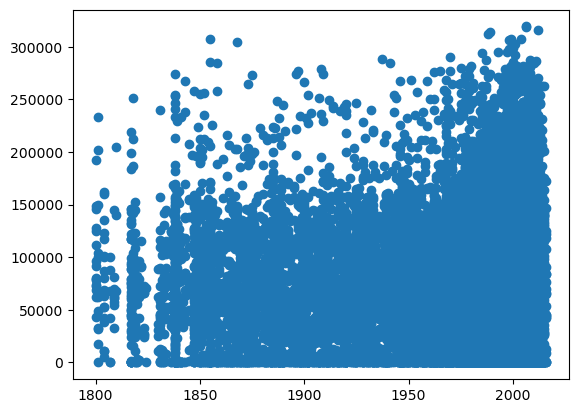

In [60]:
plt.scatter(visa_df['yr_of_estab'],visa_df['prevailing_wage'])

In [71]:
# read the packages                                                                                # 53 rd class
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

$corr function$

In [64]:
visa_df.corr(numeric_only=True)

,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,1.000000,-0.017770,-0.009523
yr_of_estab,-0.017770,1.000000,0.012342
prevailing_wage,-0.009523,0.012342,1.000000


<Axes: >

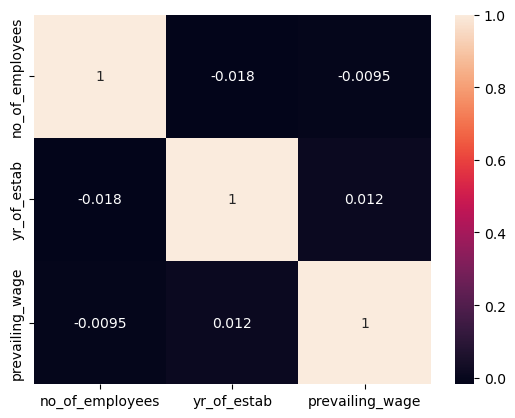

In [70]:
# above output showing values in a matrcix
# showing values in a picture:Heatmap
corr_data=visa_df.corr(numeric_only=True)
sns.heatmap(corr_data,annot=True)                               # in output picture see 1=skin color  0=black

In [94]:
# example

file_path="C:\\Users\\SIDDESH R M\\Downloads\\winequality-red.csv"
wine_df=pd.read_csv(file_path,sep=';')
wine_df.head(10)
wine_df.corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


<Axes: >

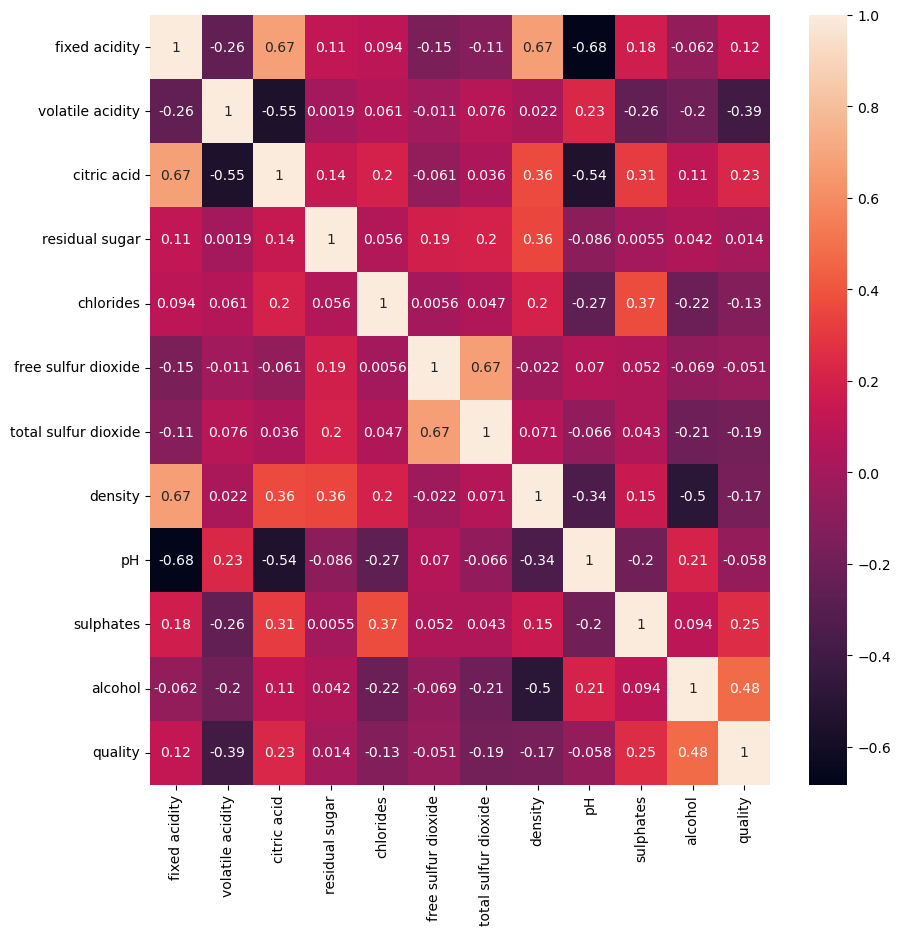

In [76]:
plt.figure(figsize=(10,10))
sns.heatmap(wine_df.corr(),annot=True)

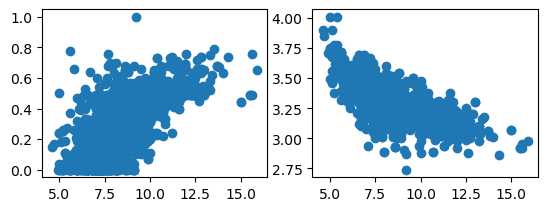

In [92]:
plt.subplot(2,2,1)
plt.scatter(wine_df['fixed acidity'],wine_df['citric acid'])
plt.subplot(2,2,2)
plt.scatter(wine_df['fixed acidity'],wine_df['pH'])